In [92]:
import sys
print(sys.executable)

c:\Users\madhu\OneDrive\Desktop\IN3\.venv\Scripts\python.exe


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [94]:
students = pd.read_csv("data/StudentsPerformance.csv")

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [95]:
print("Number of rows:", students.shape[0])
print("Number of columns:", students.shape[1])

Number of rows: 1000
Number of columns: 8


In [96]:
students.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [97]:
print("Data Types:")
print(students.dtypes)

print("\nMissing Values:")
print(students.isnull().sum())

Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [98]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [99]:
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [100]:
print("Duplicate rows:", students.duplicated().sum())

Duplicate rows: 0


In [101]:
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for column in categorical_columns:
    print("\n", column)
    print(students[column].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [102]:
students["total_score"] = (
    students["math score"]
    + students["reading score"]
    + students["writing score"]
)

students[[
    "math score",
    "reading score",
    "writing score",
    "total_score"
]].head()

,math score,reading score,writing score,total_score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [103]:
students["average_score"] = students[
    ["math score", "reading score", "writing score"]
].mean(axis=1)

students["average_score"].head()

0    72.666667
1    82.333333
2    92.666667
3    49.333333
4    76.333333
Name: average_score, dtype: float64

In [104]:
print("Students:", len(students))
print("Subjects:", 3)
print("Average total score:", round(students["total_score"].mean(), 2))
print("Average score:", round(students["average_score"].mean(), 2))
print("Highest total score:", students["total_score"].max())

Students: 1000
Subjects: 3
Average total score: 203.31
Average score: 67.77
Highest total score: 300


In [105]:
parental_education_scores = students.groupby(
    "parental level of education"
)[
    ["math score", "reading score", "writing score", "average_score"]
].mean().round(2)

parental_education_scores

,math score,reading score,writing score,average_score
parental level of education,,,,
associate's degree,67.88,70.93,69.90,69.57
bachelor's degree,69.39,73.00,73.38,71.92
high school,62.14,64.70,62.45,63.10
master's degree,69.75,75.37,75.68,73.60
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11


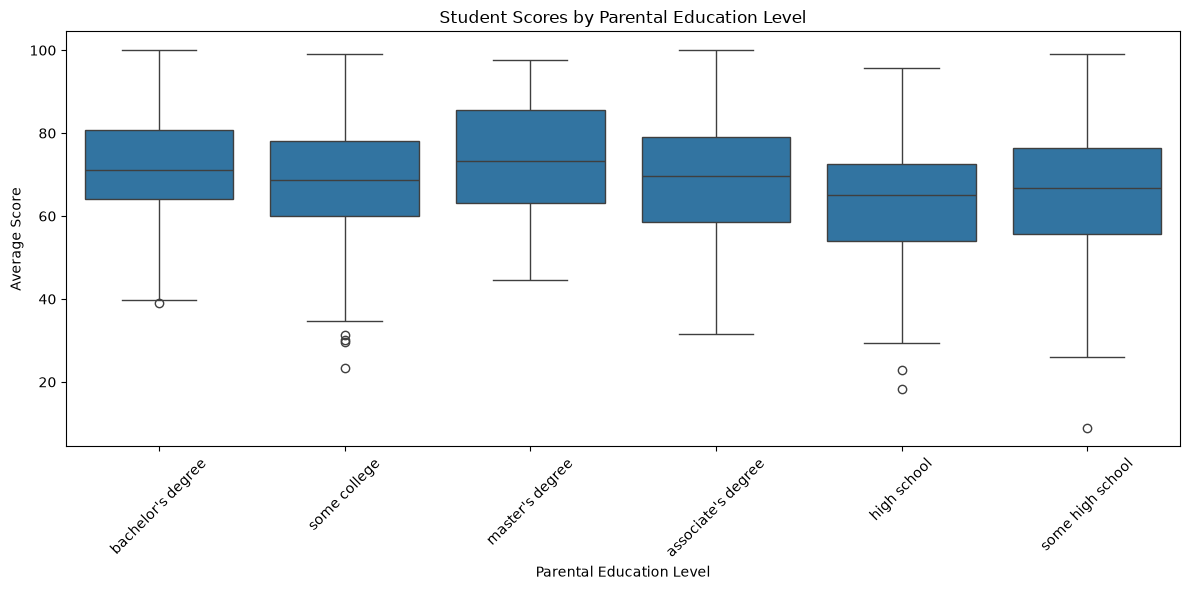

In [106]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=students,
    x="parental level of education",
    y="average_score"
)

plt.title("Student Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/scores_by_parental_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
test_prep_scores = students.groupby(
    "test preparation course"
)[
    ["math score", "reading score", "writing score", "average_score"]
].mean().round(2)

test_prep_scores

,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


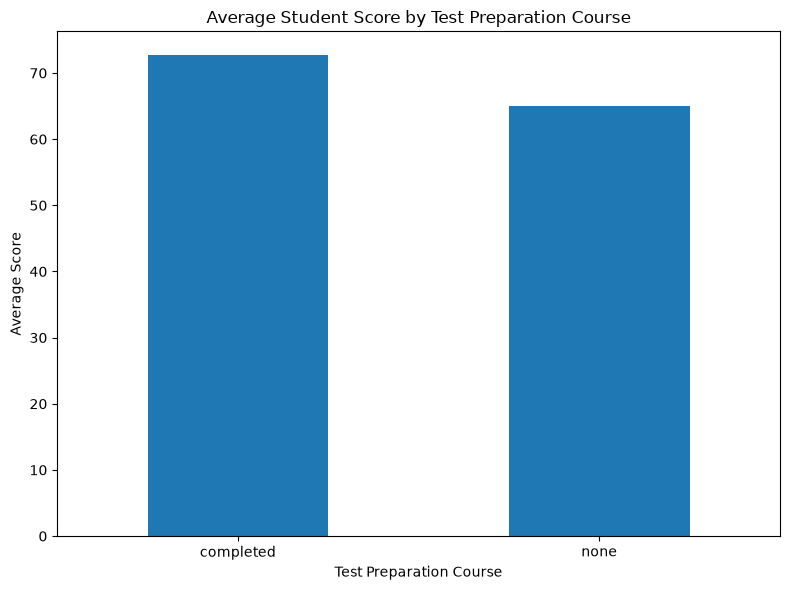

In [108]:
plt.figure(figsize=(8, 6))

test_prep_scores["average_score"].plot(
    kind="bar"
)

plt.title("Average Student Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "charts/test_preparation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
completed_score = test_prep_scores.loc[
    "completed", "average_score"
]

none_score = test_prep_scores.loc[
    "none", "average_score"
]

difference = completed_score - none_score

print("Average score - Completed:", completed_score)
print("Average score - None:", none_score)
print("Difference:", round(difference, 2))

Average score - Completed: 72.67
Average score - None: 65.04
Difference: 7.63


In [110]:
better_group = test_prep_scores["average_score"].idxmax()

print("Higher-performing group:", better_group)

Higher-performing group: completed


In [111]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

correlation_matrix = students[score_columns].corr().round(2)

correlation_matrix

,math score,reading score,writing score
math score,1.00,0.82,0.80
reading score,0.82,1.00,0.95
writing score,0.80,0.95,1.00


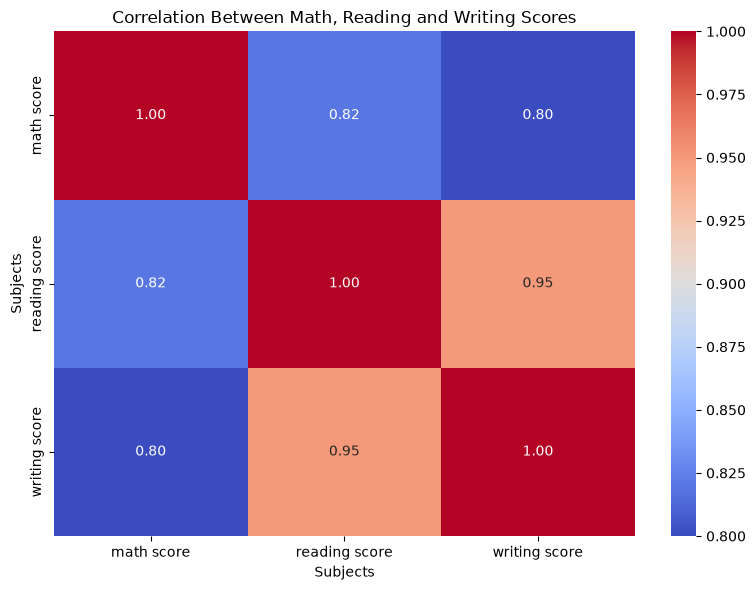

In [112]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Math, Reading and Writing Scores")
plt.xlabel("Subjects")
plt.ylabel("Subjects")

plt.tight_layout()

plt.savefig(
    "charts/score_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
correlation_pairs = (
    students[score_columns]
    .corr()
    .where(lambda x: np.triu(np.ones(x.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

correlation_pairs

reading score  writing score    0.954598
math score     reading score    0.817580
               writing score    0.802642
               math score            NaN
reading score  math score            NaN
               reading score         NaN
writing score  math score            NaN
               reading score         NaN
               writing score         NaN
dtype: float64

In [114]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder is ready!")

Charts folder is ready!


In [115]:
plt.savefig(
    "charts/scores_by_parental_education.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [116]:
os.listdir("charts")

['at_risk_by_parental_education.png',
 'correlation_heatmap.png',
 'gender_vs_subject.png',
 'reading_vs_math.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png',
 'total_score_distribution.png']

In [117]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder is ready!")

Charts folder is ready!


In [118]:
os.listdir("charts")

['at_risk_by_parental_education.png',
 'correlation_heatmap.png',
 'gender_vs_subject.png',
 'reading_vs_math.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png',
 'total_score_distribution.png']

In [119]:
print("Chart 1 completed successfully!")

Chart 1 completed successfully!


In [120]:
test_prep_scores = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

test_prep_scores.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()

plt.savefig(
    "charts/test_prep_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'df' is not defined

In [ ]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
better_group                str          completed
categorical_columns         list         n=5
column                      str          test preparation course
completed_score             float64      72.67
correlation_matrix          DataFrame    Shape: (3, 3)
correlation_pairs           Series       Shape: (9,)
difference                  float64      7.6299999999999955
none_score                  float64      65.04
np                          module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
os                          module       <module 'os' (frozen)>
parental_education_scores   DataFrame    Shape: (6, 4)
pd                          module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                         module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
score_columns               list         n=3
sns                 

In [ ]:
test_prep_scores

,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


In [ ]:
os.listdir("charts")

['scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png']

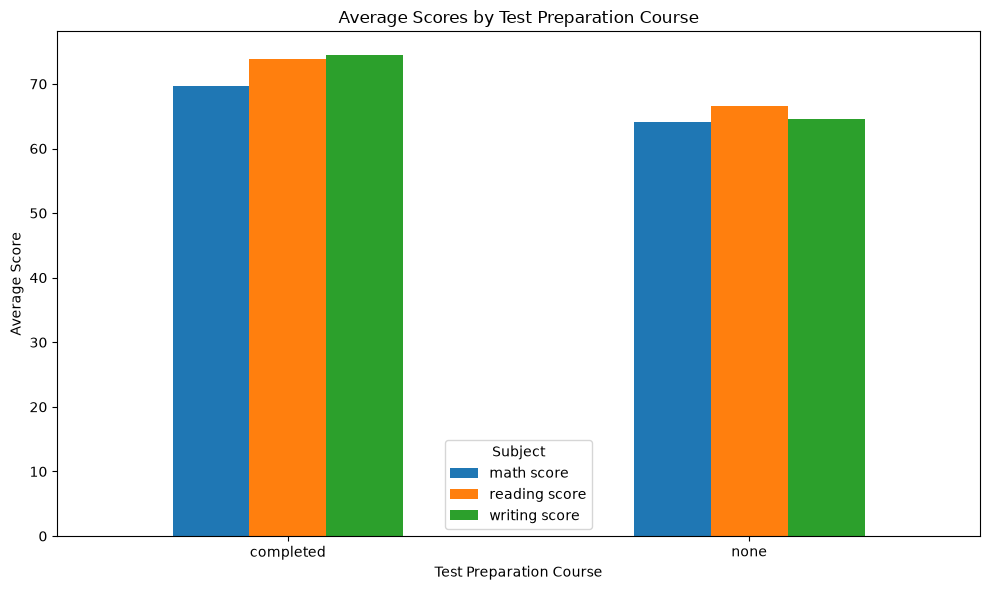

In [ ]:
test_prep_scores = students.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

test_prep_scores.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.tight_layout()

plt.savefig(
    "charts/test_prep_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("Chart 2 completed!")
print(os.listdir("charts"))

Chart 2 completed!
['scores_by_parental_education.png', 'score_correlation_heatmap.png', 'test_preparation_comparison.png', 'test_prep_comparison.png']


In [ ]:
correlation_matrix = students[
    ["math score", "reading score", "writing score"]
].corr()

correlation_matrix

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


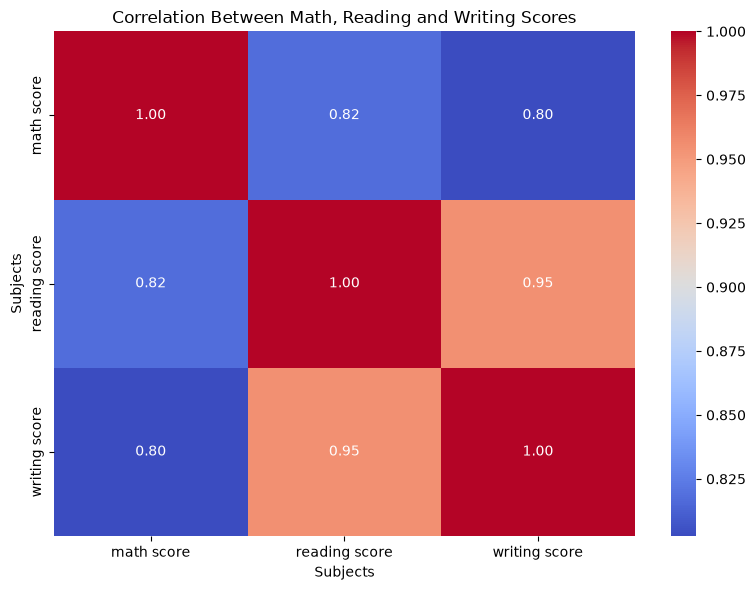

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Math, Reading and Writing Scores")
plt.xlabel("Subjects")
plt.ylabel("Subjects")

plt.tight_layout()

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
correlation_pairs = correlation_matrix.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0) !=
    correlation_pairs.index.get_level_values(1)
]

correlation_pairs.sort_values(ascending=False).head(2)

writing score  reading score    0.954598
reading score  writing score    0.954598
dtype: float64

In [ ]:
os.listdir("charts")

['correlation_heatmap.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png']

In [ ]:
gender_scores = students.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


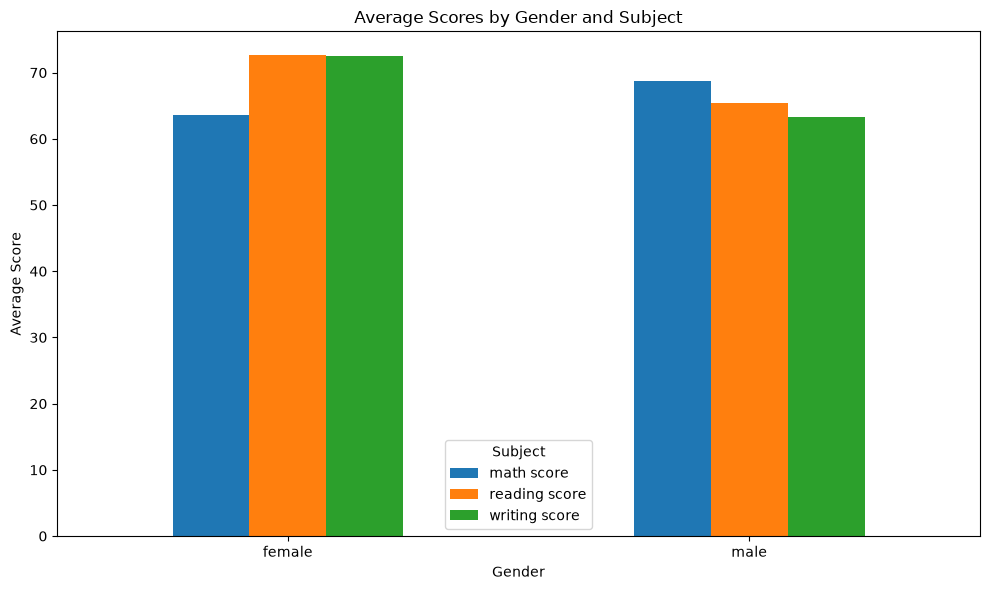

In [ ]:
gender_scores.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Scores by Gender and Subject")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.tight_layout()

plt.savefig(
    "charts/gender_vs_subject.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("Average Scores:")
print(gender_scores)

print("\nHigher-scoring gender by subject:")

for subject in gender_scores.columns:
    better_gender = gender_scores[subject].idxmax()
    score = gender_scores[subject].max()
    print(f"{subject}: {better_gender} ({score:.2f})")

Average Scores:
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203

Higher-scoring gender by subject:
math score: male (68.73)
reading score: female (72.61)
writing score: female (72.47)


In [ ]:
os.listdir("charts")

['correlation_heatmap.png',
 'gender_vs_subject.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png']

In [ ]:
students["total_score"] = (
    students["math score"]
    + students["reading score"]
    + students["writing score"]
)

students[["math score", "reading score", "writing score", "total_score"]].head()

,math score,reading score,writing score,total_score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [ ]:
students["total_score"].describe()

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total_score, dtype: float64

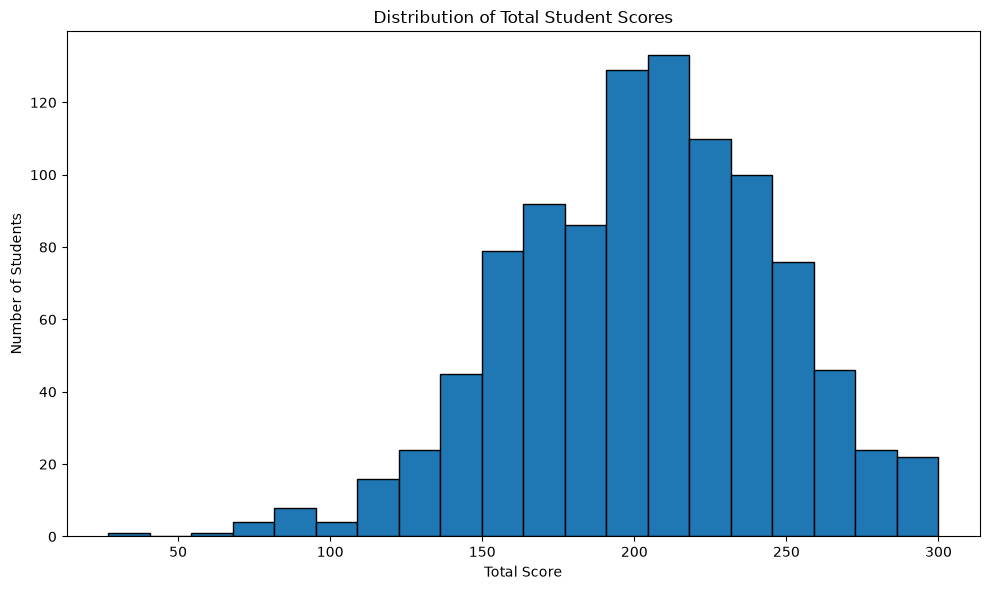

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    students["total_score"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Total Student Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    "charts/total_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
os.listdir("charts")

['correlation_heatmap.png',
 'gender_vs_subject.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png',
 'total_score_distribution.png']

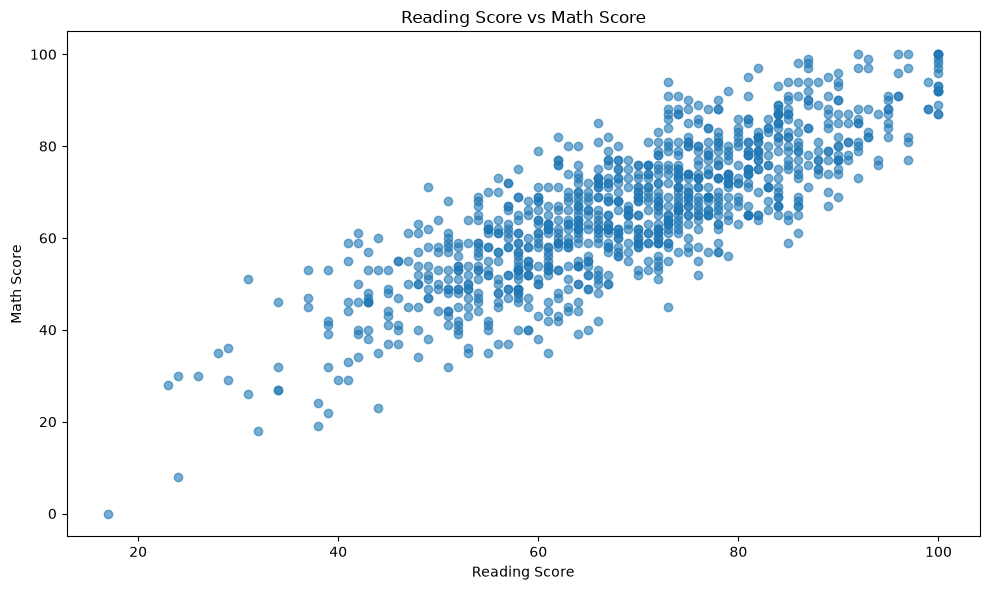

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    students["reading score"],
    students["math score"],
    alpha=0.6
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.tight_layout()

plt.savefig(
    "charts/reading_vs_math.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
reading_math_correlation = students[
    ["reading score", "math score"]
].corr().iloc[0, 1]

print(f"Reading-Math Correlation: {reading_math_correlation:.2f}")

Reading-Math Correlation: 0.82


In [ ]:
os.listdir("charts")

['correlation_heatmap.png',
 'gender_vs_subject.png',
 'reading_vs_math.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png',
 'total_score_distribution.png']

In [ ]:
students["at_risk"] = (
    (students["math score"] < 50) |
    (students["reading score"] < 50) |
    (students["writing score"] < 50)
)

students["at_risk"].value_counts()

at_risk
False    812
True     188
Name: count, dtype: int64

In [ ]:
at_risk_count = students["at_risk"].sum()
total_students = len(students)

print("Total students:", total_students)
print("At-risk students:", at_risk_count)
print("Not at-risk students:", total_students - at_risk_count)

Total students: 1000
At-risk students: 188
Not at-risk students: 812


In [ ]:
import sys
print(sys.executable)

c:\Users\madhu\OneDrive\Desktop\IN3\.venv\Scripts\python.exe


In [ ]:
students[students["at_risk"]][
    ["gender", "parental level of education",
     "test preparation course",
     "math score", "reading score", "writing score",
     "total_score"]
].head(10)

NameError: name 'students' is not defined

In [ ]:
import pandas as pd

students = pd.read_csv("data/StudentsPerformance.csv")

print(students.shape)
students.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
students["total_score"] = (
    students["math score"]
    + students["reading score"]
    + students["writing score"]
)

students[["math score", "reading score", "writing score", "total_score"]].head()

,math score,reading score,writing score,total_score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [ ]:
students["at_risk"] = (
    (students["math score"] < 50) |
    (students["reading score"] < 50) |
    (students["writing score"] < 50)
)

In [ ]:
print("Total students:", len(students))
print("At-risk students:", students["at_risk"].sum())
print("At-risk percentage:", students["at_risk"].mean() * 100)

Total students: 1000
At-risk students: 188
At-risk percentage: 18.8


In [ ]:
risk_by_gender = (
    students.groupby("gender")["at_risk"]
    .mean()
    .mul(100)
    .round(2)
)

risk_by_gender

gender
female    17.18
male      20.54
Name: at_risk, dtype: float64

In [ ]:
risk_by_prep = (
    students.groupby("test preparation course")["at_risk"]
    .mean()
    .mul(100)
    .round(2)
)

risk_by_prep

test preparation course
completed    10.06
none         23.68
Name: at_risk, dtype: float64

In [ ]:
risk_by_education = (
    students.groupby("parental level of education")["at_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

risk_by_education

parental level of education
some high school      25.70
high school           25.00
some college          16.81
associate's degree    14.86
bachelor's degree     13.56
master's degree       10.17
Name: at_risk, dtype: float64

In [ ]:
risk_summary = pd.DataFrame({
    "Group": [
        "Gender",
        "Test Preparation",
        "Parental Education"
    ],
    "Highest At-Risk Percentage": [
        risk_by_gender.max(),
        risk_by_prep.max(),
        risk_by_education.max()
    ]
})

risk_summary

,Group,Highest At-Risk Percentage
0,Gender,20.54
1,Test Preparation,23.68
2,Parental Education,25.70


In [ ]:
risk_table = pd.DataFrame({
    "Total Students": [len(students)],
    "At-Risk Students": [students["at_risk"].sum()],
    "Not At-Risk Students": [(~students["at_risk"]).sum()],
    "At-Risk Percentage": [students["at_risk"].mean() * 100]
})

risk_table

,Total Students,At-Risk Students,Not At-Risk Students,At-Risk Percentage
0,1000,188,812,18.8


In [ ]:
education_risk_table = (
    students.groupby("parental level of education")
    .agg(
        total_students=("at_risk", "size"),
        at_risk_students=("at_risk", "sum"),
        at_risk_percentage=("at_risk", "mean")
    )
)

education_risk_table["at_risk_percentage"] = (
    education_risk_table["at_risk_percentage"] * 100
).round(2)

education_risk_table = education_risk_table.sort_values(
    "at_risk_percentage",
    ascending=False
)

education_risk_table

,total_students,at_risk_students,at_risk_percentage
parental level of education,,,
some high school,179,46,25.70
high school,196,49,25.00
some college,226,38,16.81
associate's degree,222,33,14.86
bachelor's degree,118,16,13.56
master's degree,59,6,10.17


In [ ]:
education_risk_table = (
    students.groupby("parental level of education")
    .agg(
        total_students=("at_risk", "size"),
        at_risk_students=("at_risk", "sum"),
        at_risk_percentage=("at_risk", "mean")
    )
)

education_risk_table["at_risk_percentage"] = (
    education_risk_table["at_risk_percentage"] * 100
).round(2)

education_risk_table = education_risk_table.sort_values(
    "at_risk_percentage",
    ascending=False
)

education_risk_table

,total_students,at_risk_students,at_risk_percentage
parental level of education,,,
some high school,179,46,25.70
high school,196,49,25.00
some college,226,38,16.81
associate's degree,222,33,14.86
bachelor's degree,118,16,13.56
master's degree,59,6,10.17


In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    education_risk_table.index,
    education_risk_table["at_risk_percentage"]
)

plt.title("At-Risk Students by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("At-Risk Students (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "charts/at_risk_by_parental_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
education_risk_table

,total_students,at_risk_students,at_risk_percentage
parental level of education,,,
some high school,179,46,25.70
high school,196,49,25.00
some college,226,38,16.81
associate's degree,222,33,14.86
bachelor's degree,118,16,13.56
master's degree,59,6,10.17


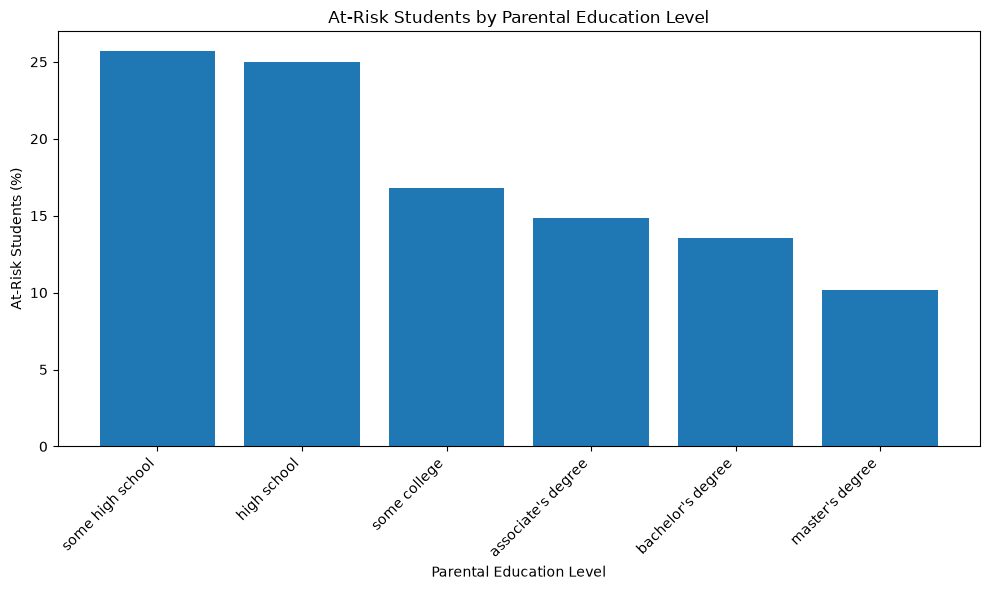

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    education_risk_table.index,
    education_risk_table["at_risk_percentage"]
)

plt.title("At-Risk Students by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("At-Risk Students (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "charts/at_risk_by_parental_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
os.listdir("charts")

NameError: name 'os' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

students = pd.read_csv("data/StudentsPerformance.csv")

print("Dataset shape:", students.shape)
students.head()

Dataset shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
students["total_score"] = (
    students["math score"]
    + students["reading score"]
    + students["writing score"]
)

students["at_risk"] = (
    (students["math score"] < 50) |
    (students["reading score"] < 50) |
    (students["writing score"] < 50)
)

print("Total students:", len(students))
print("At-risk students:", students["at_risk"].sum())

Total students: 1000
At-risk students: 188


In [ ]:
education_risk_table = students.groupby(
    "parental level of education"
)["at_risk"].mean().sort_values(ascending=False) * 100

education_risk_table

parental level of education
some high school      25.698324
high school           25.000000
some college          16.814159
associate's degree    14.864865
bachelor's degree     13.559322
master's degree       10.169492
Name: at_risk, dtype: float64

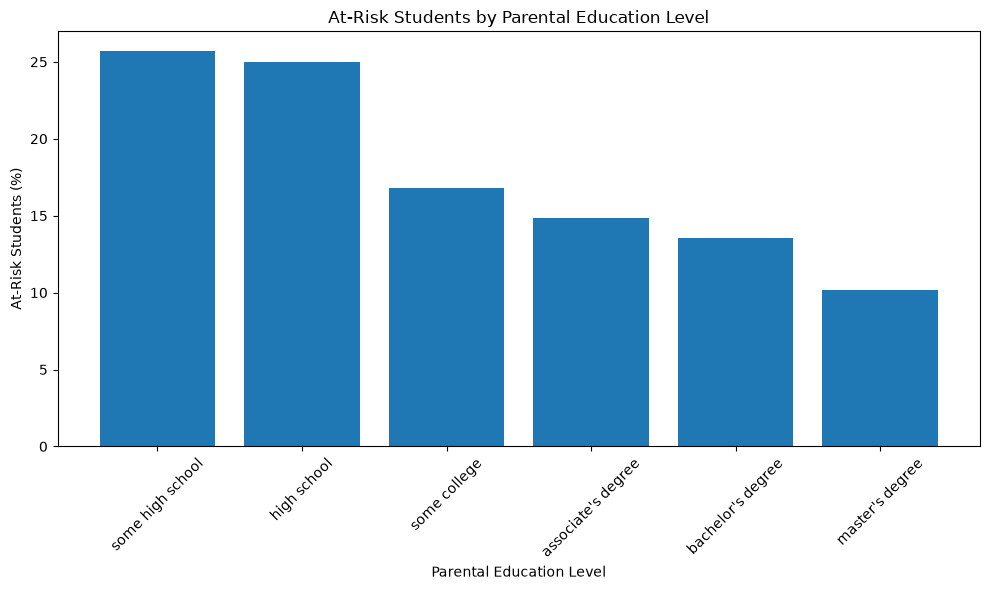

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    education_risk_table.index,
    education_risk_table.values
)

plt.title("At-Risk Students by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("At-Risk Students (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "charts/at_risk_by_parental_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
os.makedirs("charts", exist_ok=True)

In [ ]:
print("Total students:", len(students))
print("At-risk students:", students["at_risk"].sum())
print("At-risk percentage:", round(students["at_risk"].mean() * 100, 2), "%")

Total students: 1000
At-risk students: 188
At-risk percentage: 18.8 %


In [ ]:
gender_risk = (
    students.groupby("gender")["at_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

gender_risk

gender
male      20.54
female    17.18
Name: at_risk, dtype: float64

In [ ]:
prep_risk = (
    students.groupby("test preparation course")["at_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

prep_risk

test preparation course
none         23.68
completed    10.06
Name: at_risk, dtype: float64

In [ ]:
print("Highest-risk gender:")
print(gender_risk.idxmax(), "-", gender_risk.max(), "%")

print("\nHighest-risk test preparation group:")
print(prep_risk.idxmax(), "-", prep_risk.max(), "%")

Highest-risk gender:
male - 20.54 %

Highest-risk test preparation group:
none - 23.68 %


In [ ]:
at_risk_students = students[students["at_risk"]][
    [
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course",
        "math score",
        "reading score",
        "writing score",
        "total_score"
    ]
]

at_risk_students.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
7,male,group B,some college,free/reduced,none,40,43,39,122
9,female,group B,high school,free/reduced,none,38,60,50,148
11,male,group D,associate's degree,standard,none,40,52,43,135
17,female,group B,some high school,free/reduced,none,18,32,28,78
18,male,group C,master's degree,free/reduced,completed,46,42,46,134
22,male,group D,some college,standard,none,44,54,53,151
33,male,group D,some college,standard,none,40,42,38,120
50,male,group E,some college,standard,none,53,55,48,156
52,male,group C,some college,standard,none,53,44,42,139


In [ ]:
overall_scores = students[
    ["math score", "reading score", "writing score"]
].mean().round(2)

overall_scores

math score       66.09
reading score    69.17
writing score    68.05
dtype: float64

In [ ]:
prep_scores = students.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

prep_scores

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


In [ ]:
gender_scores = students.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

gender_scores

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [ ]:
print("Average total score:", round(students["total_score"].mean(), 2))
print("Highest total score:", students["total_score"].max())
print("Lowest total score:", students["total_score"].min())

Average total score: 203.31
Highest total score: 300
Lowest total score: 27


In [ ]:
os.listdir("charts")

['at_risk_by_parental_education.png',
 'correlation_heatmap.png',
 'gender_vs_subject.png',
 'reading_vs_math.png',
 'scores_by_parental_education.png',
 'score_correlation_heatmap.png',
 'test_preparation_comparison.png',
 'test_prep_comparison.png',
 'total_score_distribution.png']

# Principal's Report

## Executive Summary

This analysis examined the academic performance of 1,000 students and identified key factors associated with their mathematics, reading, and writing scores. The analysis found that test preparation, parental education, and differences between student groups are associated with variations in academic performance. In addition, 188 students were identified as at-risk because they scored below 50 in at least one subject.

## Key Findings

1. **Test Preparation:** Students who completed the test preparation course achieved higher average scores than students who did not complete it, showing that additional academic preparation can support better performance.

2. **Parental Education:** Students' performance varies across different parental education levels, suggesting that educational background may be associated with student outcomes.

3. **Reading and Mathematics Relationship:** Reading and mathematics scores showed a strong positive correlation of approximately **0.82**, meaning students who performed well in reading generally also performed well in mathematics.

4. **Gender Differences:** Performance varies between male and female students across mathematics, reading, and writing, with each group showing different strengths across subjects.

5. **At-Risk Students:** Out of 1,000 students, **188 students (18.8%)** were classified as at-risk because they scored below 50 in at least one subject.

## Actionable Recommendations

1. **Provide targeted academic support:** Identify at-risk students early and provide additional tutoring, mentoring, and subject-specific support, particularly in subjects where their scores are below 50.

2. **Strengthen test preparation programs:** Encourage students to complete test preparation courses through structured revision sessions, practice tests, and additional learning resources.

3. **Introduce early performance monitoring:** Regularly monitor mathematics, reading, and writing scores to identify students whose performance is declining and provide intervention before final examinations.

## Most Impactful Recommendation

The most impactful recommendation is to strengthen early identification and targeted support for at-risk students. Since 18.8% of students were identified as at-risk, identifying these students early can help the school provide focused academic assistance before their performance declines further. Regular assessments combined with tutoring and mentoring can help improve student outcomes.
